In [ ]:
from torch.utils.data import Dataset,DataLoader
import pandas as pd 
import os
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
# from skimage.metrics import structural_similarity as ssim_fn

In [4]:
#dataclass for dependency injection



class TrainDataset(Dataset):
    def __init__(self,dir_path,csv_path,transformation=None,augment=False):
        self.prefix = "face-"
        self.dir = dir_path
        self.df = pd.read_csv(csv_path)
        self.transform = transformation
        self.augment = augment

        transforms = []
        if self.augment:
            transforms += [
        #         # PRIMARY: random crop (75-100% of image) then resize back to 64x64
        #         # This is the main anti-averaging augmentation.
        #         # scale=(0.75, 1.0) means minimum crop is 75% of original area —
        #         # floor chosen so the face always remains visible after crop.
        #         # A.RandomResizedCrop(size=(64,64), scale=(0.75, 1.0), p=0.7),
                #  A.RandomCrop(height=48, width=48, p=0.7),  # 48 = 75% of 64, face still visible
                #  A.Resize(height=64, width=64),  
        #         # Combines shift, scale, rotate in one transform.
        #         # shift_limit=0.1  : translate up to 10% of image width/height
        #         # scale_limit=0.2  : zoom in/out by up to 20%
        #         # rotate_limit=25  : rotate up to ±25° — heavier but still natural
        #         # A.ShiftScaleRotate(
        #         #     shift_limit=0.1,
        #         #     scale_limit=0.2,
        #         #     rotate_limit=25,
        #         #     border_mode=cv2.BORDER_REFLECT_101,
        #         #     p=0.6
        #         # ),

                A.Affine(
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                scale=(0.95, 1.05),
                rotate=(-10, 10),
                border_mode=cv2.BORDER_REFLECT_101,
                p=0.6
                ),
                # Horizontal flip — natural for faces, effectively doubles dataset
                A.HorizontalFlip(p=0.5),
 
                # Gaussian noise — forces robust feature learning
                # var_limit=(5,20): mild enough that face structure is preserved
                # A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
                # A.GaussNoise(std_range=(0.02, 0.09), p=0.3),
               
 
                # # Heavier lighting variation than before (0.2 vs 0.1 previously)
                # A.RandomBrightnessContrast(
                #     brightness_limit=0.2,
                #     contrast_limit=0.2,
                #     p=0.4
                # ),
                A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.3
            ),

                A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
            ]
 
        transforms += [
            A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0],
                        max_pixel_value=255.0),
            ToTensorV2()
        ]
        self.transforms = A.Compose(transforms)
 
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        label = int(self.df.iloc[index]["glasses"])
        img_name = self.prefix + f"{index + 1}.png"
        img_path = os.path.join(self.dir, img_name)

        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # normalize to [0,1]
        # img = img / 255.0
       
        # img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        # img = self.transform(img) if self.transform else img
        img = self.transforms(image=img)["image"]
        # img = img.numpy()
        return img,label
    

#dataloader


dataset = TrainDataset(
    dir_path="resized_dataset",
    csv_path="train-corrected.csv",
    augment=True
)
# dataset.augment = True
loader = DataLoader(dataset, batch_size=64, shuffle=True,pin_memory=True)

def visualize_augments(loader,n=16):
    # dataset.augment = True
    imgs,labels = next(iter(loader))

    imgs         = imgs[:n].permute(0, 2, 3, 1).numpy()
    labels       = labels[:n].numpy()

    label_names={
        1:"glasses",
        0:"no-glasses"
    }
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(imgs[i], 0, 1))
        ax.set_title(label_names[labels[i]], fontsize=8)
        ax.axis("off")
    plt.suptitle("augments visualized")
    plt.tight_layout()
    plt.show()
    # dataset.augment = False
    



In [5]:
# #VAE class

import torch
import torch.nn as nn
import torch.nn.functional as F

# class VAE(nn.Module):
#     def __init__(self, z_dim=128):
#         super().__init__()

#         # Encoder
#         self.encoder = nn.Sequential(
#             nn.Conv2d(3, 32, 4, 2, 1),   # 64 → 32
#             nn.LeakyReLU(),
#             nn.Conv2d(32, 64, 4, 2, 1),  # 32 → 16
#             nn.LeakyReLU(),
#             nn.Conv2d(64, 128, 4, 2, 1), # 16 → 8
#             nn.LeakyReLU(),
#         )

#         self.fc_mu = nn.Linear(128 * 8 * 8, z_dim)
#         self.fc_logvar = nn.Linear(128 * 8 * 8, z_dim)

#         # Decoder
#         self.fc_dec = nn.Linear(z_dim, 128 * 8 * 8)

#         self.decoder = nn.Sequential(
#             nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 → 16
#             nn.LeakyReLU(),
#             nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16 → 32
#             nn.LeakyReLU(),
#             nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32 → 64
#             nn.Sigmoid()
#         )

#     def encode(self, x):
#         x = self.encoder(x)
#         x = x.view(x.size(0), -1)
#         mu = self.fc_mu(x)
#         logvar = self.fc_logvar(x)
#         return mu, logvar

#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + eps * std

#     def decode(self, z):
#         x = self.fc_dec(z)
#         x = x.view(-1, 128, 8, 8)
#         return self.decoder(x)

#     def forward(self, x):
#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)
#         recon = self.decode(z)
#         return recon, mu, logvar



# def vae_loss(recon_x, x, mu, logvar, beta=0.05):
#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction='mean')

#     kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

#     return recon_loss + beta * kl


class VAE(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.z_dim = z_dim
        self.label_emb = nn.Embedding(2, 16)

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
    

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*8*8 + 16, z_dim)
        self.fc_logvar = nn.Linear(128*8*8 + 16, z_dim)

        self.fc_dec = nn.Linear(z_dim + 16, 128*8*8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x, y):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        y_emb = self.label_emb(y)
        h = torch.cat([h, y_emb], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z = torch.cat([z, y_emb], dim=1)
        h = self.fc_dec(z)
        h = h.view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, y)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    return recon_loss + beta * kl




In [ ]:
def class_level_stats(loader,model,device):
    model.eval()
    class_level_mu,class_level_std = {},{}
    mus = {
        0:[],
        1:[],
    }
    with torch.no_grad():
        for img,label in loader:
            img = img.to(device)
            mu,_ = model.encode(img)
            for i,lbl in enumerate(label):
                mus[lbl.item()].append(mu[i].cpu())

    
    for i in range(2):
        stacked = torch.stack(mus[i])
        class_level_mu[i] = stacked.mean(dim=0)
        class_level_std[i] = stacked.std(dim=0)

    return class_level_mu,class_level_std


# def conditional_sampling(model,loader,device,label,mus,stds,n_samples=3,temp=1.2):
    
#     # mus,stds = class_level_stats(loader,model,device)
#     mu = mus[label].to(device)
#     std = stds[label].to(device)
#     with torch.no_grad():
#         eps = torch.randn(n_samples,mu.shape[0],device=device)
#         z = mu + temp*std*eps
#         imgs = model.decode(z)
    
#     imgs = imgs.cpu()
#     return imgs



def visualize_generated(imgs_glasses, imgs_noglasses):
    all_imgs    = torch.cat([imgs_glasses, imgs_noglasses], dim=0)
    all_imgs_np = all_imgs.permute(0, 2, 3, 1).numpy()
    titles      = ["glasses"] * 3 + ["no glasses"] * 3
 
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(np.clip(all_imgs_np[i], 0, 1))
        ax.set_title(titles[i])
        ax.axis("off")
    plt.suptitle("Conditionally Generated Faces (VAE)")
    plt.tight_layout()
    plt.show()






In [29]:
def compute_ssim(generated, real):
    """
    Mean SSIM across N (generated, real) image pairs.
 
    Args:
        generated : (N, C, H, W) float tensor [0,1]
        real      : (N, C, H, W) float tensor [0,1]
    Returns:
        float — mean SSIM  (1.0 = identical, 0.0 = no similarity)
    """
    scores  = []
    gen_np  = generated.cpu().numpy()
    real_np = real.cpu().numpy()
 
    for g, r in zip(gen_np, real_np):
        g     = np.clip(g.transpose(1, 2, 0), 0, 1)  # CHW → HWC
        r     = np.clip(r.transpose(1, 2, 0), 0, 1)
        score = ssim_fn(g, r, channel_axis=2, data_range=1.0)
        scores.append(score)
 
    return float(np.mean(scores))


def ssim_eval(imgs_glasses,imgs_noglasses):
    real_imgs, _ = next(iter(loader))
    real_sample   = real_imgs[:6]
    all_generated = torch.cat([imgs_glasses, imgs_noglasses], dim=0)
 
    ssim_score = compute_ssim(all_generated, real_sample)
    print("ssim-score: ",ssim_score)


In [6]:
#train VAE
# print(device)
def train_vae(z_dim=64,beta=0.5,activation="leakyRELU",lr=1e-3,epochs=80,device="cpu",temp=1.0):
    loss_type = "MSE"
    # activation="leakyRELU"
    # z_dim=64
    # beta=0.05
    model = VAE(z_dim=z_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=False
)
    os.makedirs(f"generated/VAE/z_size={z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}",exist_ok=True)
    visualize_augments(loader)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        beta_opti = max(0.00001,min(beta,(epoch/epochs)*4*beta))
        for imgs,labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            recon, mu, logvar = model(imgs,labels)
            loss = vae_loss(recon, imgs, mu, logvar,beta_opti)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        
        # 16 images, z_dim=64
        # with torch.no_grad():
        #     z = torch.randn(1, z_dim).to(device)*temp 
        #     y0 = torch.tensor([0]).to(device)
        #     y1 = torch.tensor([1]).to(device)
        #     generated0 = model.decode(z,y0)[0]
        #     generated1 = model.decode(z,y1)[0]
        
        # generated0 = generated0.cpu().permute(1,2,0).numpy()*255
        # generated1 = generated1.cpu().permute(1,2,0).numpy()*255

        # generated0 = generated0.astype("uint8")
        # generated1 = generated1.astype("uint8")

        # combined = np.concat([generated0,generated1],axis=1)

        # img = cv2.cvtColor(combined,cv2.COLOR_RGB2BGR)
        # # save = cv2.resize(img,(256,256),interpolation=cv2.INTER_NEAREST)
        # # save_image(generated,f"generated/VAE/z_size={z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}/VAE_epoch_{epoch}.png")
        # cv2.imwrite(f"generated/VAE/z_size={z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}/VAE_epoch_{epoch}.png",img)
        
        
        # save_image(save,f"generated/VAE/z_size={z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}/VAE_epoch_{epoch}.png")


        print(f"Epoch {epoch}, Loss: {total_loss}")
    # class_mu,class_std = class_level_stats(loader,model,device)
        avg_loss = total_loss/len(loader)
        scheduler.step(avg_loss)
    # torch.save({
    #     "model_state":model.state_dict(),
    #     "z_dim":z_dim,
    #     "lr":lr
    # },
    # f"generated/VAE/z_size={z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}.pt")
    return model,lr,loss_type,beta,activation

In [7]:
def conditional_sampling(model,device,label,n=3):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.z_dim).to(device)
        y = torch.full((n,), label, dtype=torch.long).to(device)
        imgs = model.decode(z, y)
        return imgs.cpu()

In [ ]:
import torchvision.utils as vutils
def main():
    torch.set_float32_matmul_precision('high')
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model,lr,loss_type,beta,activation = train_vae()
    # class_level_stats(loader,model,device)
    glasses,no_glasses = conditional_sampling(model,device,1),conditional_sampling(model,device,0)
    visualize_generated(glasses,no_glasses)
    for i in range(3):
        vutils.save_image(glasses[i],f"generated/VAE/z_size={model.z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}/conditional_glasses_{i+1}.png")
        vutils.save_image(no_glasses[i],f"generated/VAE/z_size={model.z_dim}-lr={lr}-loss={loss_type}-beta={beta}-activation={activation}/conditional_no_glasses_{i+1}.png")
    # vutils.save_image(glasses,"generated/VAE/glasses.png",nrows=3)
    # vutils.save_image(no_glasses,"generated/VAE/no-glasses.png",nrows=3)
    # ssim_eval(glasses,no_glasses)

if __name__ == "__main__":
    main()

---
## VAE Ablation Study
**Cells below are self-contained — run them in order.**

Ablation table: 6 runs, one hyperparameter changed per run from a fixed baseline.
Metrics computed per run: FID · Precision & Recall · LPIPS.

In [ ]:
# Run once to install metric libraries
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "torchmetrics[image]", "lpips"],
    check=True
)
print("✅ torchmetrics + lpips installed")


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
import matplotlib.pyplot as plt


# ── Activation factory ───────────────────────────────────────────
def get_activation(name: str) -> nn.Module:
    """Return activation module by name.  Supported: relu | leakyrelu | elu."""
    _map = {
        "relu":      nn.ReLU(),
        "leakyrelu": nn.LeakyReLU(negative_slope=0.2),
        "elu":       nn.ELU(),
    }
    key = name.lower().replace("-", "").replace("_", "")
    if key not in _map:
        raise ValueError(f"Unknown activation '{name}'. Choose: {list(_map.keys())}")
    return _map[key]


# ── Conditional VAE ──────────────────────────────────────────────
class VAE(nn.Module):
    """
    Conditional VAE — class label injected via embedding at encode + decode.
    Architecture is identical to the original; only the activation is now
    parameterised instead of hardcoded to ReLU.

    Parameters saved to checkpoint (everything needed to rebuild at inference):
        z_dim      : int   — latent dimension
        activation : str   — activation function name
    """
    def __init__(self, z_dim: int = 64, activation: str = "leakyrelu"):
        super().__init__()
        self.z_dim      = z_dim
        self.activation = activation          # stored so checkpoint is self-describing
        self.label_emb  = nn.Embedding(2, 16)

        # Each layer gets its own activation instance (required — nn.Module is stateful)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),        # 64 → 32
            get_activation(activation),
            nn.Conv2d(32, 64, 4, 2, 1),       # 32 → 16
            get_activation(activation),
            nn.Conv2d(64, 128, 4, 2, 1),      # 16 → 8
            get_activation(activation),
        )

        # 128*8*8 conv features + 16-d label embedding → z
        self.fc_mu     = nn.Linear(128 * 8 * 8 + 16, z_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8 + 16, z_dim)

        # z + 16-d label embedding → 128*8*8 → decode
        self.fc_dec = nn.Linear(z_dim + 16, 128 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 8 → 16
            get_activation(activation),
            nn.Dropout(0.2),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 16 → 32
            get_activation(activation),
            nn.Dropout(0.2),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 32 → 64
            nn.Sigmoid(),                            # output always in [0, 1]
        )

    def encode(self, x, y):
        h     = self.encoder(x).view(x.size(0), -1)
        y_emb = self.label_emb(y)
        h     = torch.cat([h, y_emb], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        h     = self.fc_dec(torch.cat([z, y_emb], dim=1))
        return self.decoder(h.view(-1, 128, 8, 8))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar


# ── VAE loss ─────────────────────────────────────────────────────
def vae_loss(recon, x, mu, logvar, beta: float, loss_type: str = "MSE"):
    """
    ELBO = reconstruction_loss + beta * KL

    loss_type:
        MSE  — mean squared error (default; smooth, tends to produce blurry outputs)
        L1   — mean absolute error (linear penalty; sharper edges than MSE)

    Returns (total_loss, recon_loss_value, kl_value) as a tuple so the
    training loop can log components separately.
    """
    lt = loss_type.upper()
    if lt == "MSE":
        recon_loss = F.mse_loss(recon, x, reduction="mean")
    elif lt == "L1":
        recon_loss = F.l1_loss(recon, x, reduction="mean")
    else:
        raise ValueError(f"Unknown loss_type '{loss_type}'. Choose: MSE | L1")

    # KL: -0.5 * sum(1 + log σ² - μ² - σ²) averaged over batch
    kl         = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total      = recon_loss + beta * kl
    return total, recon_loss.item(), kl.item()


print("✅ VAE + vae_loss defined.")


✅ VAE + vae_loss defined.


In [12]:
import torch
import numpy as np
from torchvision import models, transforms
from torchmetrics.image.fid import FrechetInceptionDistance
import lpips as lpips_lib
import torch.nn as nn


# ── Clean eval DataLoader (no augmentation) ───────────────────────
# TrainDataset builds transforms once in __init__ based on augment flag,
# so we instantiate a separate dataset object with augment=False.
eval_dataset = TrainDataset(
    dir_path="resized_dataset",
    csv_path="train-corrected.csv",
    augment=False
)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False, pin_memory=True)
print(f"✅ eval_loader ready — {len(eval_dataset)} images, no augmentation")


# ── Constants ─────────────────────────────────────────────────────
EVAL_N      = 500    # total generated images per run for FID/PR (250 per class)
PR_K        = 3      # k for k-NN manifold radius in Precision & Recall
LPIPS_REAL  = 100    # real images used as LPIPS reference pool


# ── InceptionV3 feature extractor (shared by FID + PR) ───────────
class _InceptionFeatures(nn.Module):
    """Pool3 (2048-d) features from InceptionV3. Input: (N,3,H,W) in [0,1]."""
    def __init__(self, device):
        super().__init__()
        m           = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        m.fc        = nn.Identity()
        m.aux_logits = False
        self.model  = m.eval().to(device)
        self.resize = transforms.Resize((299, 299), antialias=True)
        self.device = device

    @torch.no_grad()
    def forward(self, imgs):
        imgs = self.resize(imgs).to(self.device)
        imgs = imgs * 2.0 - 1.0          # [0,1] → [-1,1] (InceptionV3 convention)
        return self.model(imgs)           # (N, 2048)


# ── Batch generators ──────────────────────────────────────────────
@torch.no_grad()
def _generate_batch(model, device, label: int, n: int, bs: int = 64):
    """Generate n images for one class label. Returns (n,3,H,W) CPU float [0,1]."""
    model.eval()
    chunks, done = [], 0
    while done < n:
        b    = min(bs, n - done)
        z    = torch.randn(b, model.z_dim).to(device)
        y    = torch.full((b,), label, dtype=torch.long).to(device)
        chunks.append(model.decode(z, y).cpu())
        done += b
    return torch.cat(chunks)


@torch.no_grad()
def _real_batch(n: int):
    """Pull n real images from eval_loader. Returns (n,3,H,W) CPU float [0,1]."""
    chunks, done = [], 0
    for imgs, _ in eval_loader:
        chunks.append(imgs.clamp(0, 1))
        done += imgs.size(0)
        if done >= n:
            break
    return torch.cat(chunks)[:n]


# ╔══════════════════════════════════════════════════════════════╗
# ║  FID                                                         ║
# ╚══════════════════════════════════════════════════════════════╝
def compute_fid(real: torch.Tensor, fake: torch.Tensor, device: str) -> float:
    """
    Fréchet Inception Distance.
    Inputs: (N,3,H,W) float [0,1].  Lower = better.
    normalize=True lets torchmetrics accept float [0,1] directly.
    """
    metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    metric.update(real.to(device), real=True)
    metric.update(fake.to(device), real=False)
    return float(metric.compute())


# ╔══════════════════════════════════════════════════════════════╗
# ║  Precision & Recall                                          ║
# ╚══════════════════════════════════════════════════════════════╝
def _knn_radii(feats: torch.Tensor, k: int) -> torch.Tensor:
    """Distance to k-th nearest neighbour for each point (self excluded)."""
    # Squared L2 distance matrix via ||a-b||² = ||a||² + ||b||² - 2 a·bᵀ
    a2  = (feats ** 2).sum(1, keepdim=True)         # (N,1)
    dist = a2 + a2.T - 2 * feats @ feats.T          # (N,N)
    dist.fill_diagonal_(float("inf"))
    knn, _ = dist.topk(k, dim=1, largest=False)     # (N,k)
    return knn[:, -1]                               # k-th neighbour distance


def compute_precision_recall(real_f: torch.Tensor,
                              fake_f: torch.Tensor,
                              k:      int = PR_K) -> tuple:
    """
    Improved Precision & Recall (Kynkäänniemi et al., 2019).
    Inputs: InceptionV3 pool3 features, (N,2048).

    Precision: fraction of fake points inside the real manifold  → fidelity
    Recall   : fraction of real points covered by the fake manifold → diversity
    Both in [0,1].  Higher is better.
    """
    real_r  = _knn_radii(real_f, k)                          # (N_real,)
    fake_r  = _knn_radii(fake_f, k)                          # (N_fake,)

    # (N_fake, N_real) squared distances
    a2  = (fake_f ** 2).sum(1, keepdim=True)
    b2  = (real_f ** 2).sum(1, keepdim=True)
    dfr = a2 + b2.T - 2 * fake_f @ real_f.T

    # Precision: fake point in real manifold if dist² ≤ real radius for any real point
    precision = (dfr <= real_r.unsqueeze(0)).any(dim=1).float().mean().item()

    # Recall: real point covered if any fake point is within fake radius
    recall    = (dfr.T <= fake_r.unsqueeze(0)).any(dim=1).float().mean().item()

    return precision, recall


# ╔══════════════════════════════════════════════════════════════╗
# ║  LPIPS                                                       ║
# ╚══════════════════════════════════════════════════════════════╝
def compute_lpips(generated: torch.Tensor,
                  real_pool: torch.Tensor,
                  device:    str) -> float:
    """
    Mean nearest-neighbour LPIPS distance.
    For each generated image, find the closest real image by LPIPS and record
    that distance.  Averaging these gives a fidelity score (lower = better).

    Works reliably at small N — no distributional assumptions needed.
    Uses AlexNet backbone (fast, perceptually well-calibrated on faces).
    """
    loss_fn = lpips_lib.LPIPS(net="alex", verbose=False).to(device)

    # LPIPS expects [-1, 1]
    gen_s  = (generated.to(device)  * 2 - 1).clamp(-1, 1)
    real_s = (real_pool.to(device)  * 2 - 1).clamp(-1, 1)

    scores = []
    with torch.no_grad():
        for g in gen_s:
            g_rep = g.unsqueeze(0).expand(real_s.size(0), -1, -1, -1)
            d     = loss_fn(g_rep, real_s)          # (N_real, 1, 1, 1)
            scores.append(d.min().item())           # nearest-neighbour distance
    return float(np.mean(scores))


# ╔══════════════════════════════════════════════════════════════╗
# ║  run_metrics — called once per ablation run                  ║
# ╚══════════════════════════════════════════════════════════════╝
def run_metrics(model, device: str) -> dict:
    """
    Compute FID, Precision, Recall, LPIPS for one trained model.

    FID + PR  — use EVAL_N generated images (250 glasses + 250 no-glasses)
                and EVAL_N real images from eval_loader.
    LPIPS     — uses the 6 display images vs a pool of LPIPS_REAL real images.
    """
    print("  Computing metrics...", end=" ", flush=True)

    # Generated images
    fake_glasses    = _generate_batch(model, device, label=1, n=EVAL_N // 2)
    fake_noglasses  = _generate_batch(model, device, label=0, n=EVAL_N // 2)
    fake_all        = torch.cat([fake_glasses, fake_noglasses])   # (EVAL_N, 3, H, W)

    # Real images
    real_all        = _real_batch(EVAL_N)                         # (EVAL_N, 3, H, W)
    real_lpips_pool = _real_batch(LPIPS_REAL)

    # FID
    fid = compute_fid(real_all, fake_all, device)
    print(f"FID={fid:.2f}", end=" | ", flush=True)

    # PR — extract Inception features once for both
    backbone = _InceptionFeatures(device)
    real_f   = backbone(real_all).cpu().float()
    fake_f   = backbone(fake_all).cpu().float()
    del backbone
    prec, rec = compute_precision_recall(real_f, fake_f)
    print(f"Prec={prec:.3f} Rec={rec:.3f}", end=" | ", flush=True)

    # LPIPS on the 6 display images (3 glasses + 3 no-glasses)
    display_6 = torch.cat([fake_glasses[:3], fake_noglasses[:3]])
    lpips_val = compute_lpips(display_6, real_lpips_pool, device)
    print(f"LPIPS={lpips_val:.4f}")

    return {
        "fid":       round(fid,       4),
        "precision": round(prec,      4),
        "recall":    round(rec,       4),
        "lpips":     round(lpips_val, 4),
    }


print("✅ Metrics (FID, Precision & Recall, LPIPS) + eval_loader ready.")


✅ eval_loader ready — 4500 images, no augmentation
✅ Metrics (FID, Precision & Recall, LPIPS) + eval_loader ready.


In [14]:
import torchvision.utils as vutils
import pandas as pd


# ── Visualise 3+3 conditional samples ────────────────────────────
def visualize_generated(imgs_glasses, imgs_noglasses,
                        title="Conditionally Generated Faces (VAE)"):
    all_imgs = torch.cat([imgs_glasses, imgs_noglasses]).permute(0, 2, 3, 1).numpy()
    titles   = ["glasses"] * 3 + ["no glasses"] * 3
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(np.clip(all_imgs[i], 0, 1))
        ax.set_title(titles[i])
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ── Main ablation training function ──────────────────────────────
def train_vae_ablation(
    run_tag    : str,
    z_dim      : int   = 64,
    beta       : float = 0.5,
    activation : str   = "leakyrelu",
    lr         : float = 1e-3,
    loss_type  : str   = "MSE",
    epochs     : int   = 80,
    device     : str   = "cpu",
) -> dict:
    """
    Train one ablation run, save weights + display images, compute metrics.

    Saves
    -----
    Weights  : generated/VAE/{run_tag}.pt
               Contains: model_state_dict, z_dim, activation
               (Everything needed to reconstruct VAE at inference time)
    Images   : generated/VAE/{run_tag}/glasses_{1-3}.png
                                       no_glasses_{1-3}.png

    Returns
    -------
    dict with all hyperparams + final loss components + metric scores.
    """
    os.makedirs(f"generated/VAE/{run_tag}", exist_ok=True)

    print(f"\n{'='*65}")
    print(f"  {run_tag}")
    print(f"  z_dim={z_dim} | lr={lr} | beta={beta} | "
          f"activation={activation} | loss={loss_type}")
    print(f"{'='*65}")

    model     = VAE(z_dim=z_dim, activation=activation).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5, verbose=False
    )

    final_recon = final_kl = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = total_recon = total_kl = 0.0

        # Beta warmup: ramp from ~0 → target beta over first half of training
        beta_now = max(1e-5, min(beta, (epoch / epochs) * 4 * beta))

        for imgs, labels in loader:            # augmented training loader (global)
            imgs, labels = imgs.to(device), labels.to(device)
            recon, mu, logvar = model(imgs, labels)
            loss, rl, kl_val  = vae_loss(recon, imgs, mu, logvar,
                                          beta=beta_now, loss_type=loss_type)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss  += loss.item()
            total_recon += rl
            total_kl    += kl_val

        n_batches   = len(loader)
        avg_loss    = total_loss  / n_batches
        final_recon = total_recon / n_batches
        final_kl    = total_kl    / n_batches
        scheduler.step(avg_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs}  "
                  f"loss={avg_loss:.4f}  recon={final_recon:.4f}  "
                  f"kl={final_kl:.4f}  beta_now={beta_now:.4f}")

    # ── Save weights (only what VAE.__init__ needs) ───────────────
    ckpt_path = f"generated/VAE/{run_tag}.pt"
    torch.save({
        "model_state": model.state_dict(),
        "z_dim":       z_dim,
        "activation":  activation,
        "beta": beta,
        "loss_type": loss_type
    }, ckpt_path)
    print(f"  ✅ Weights → {ckpt_path}")

    # ── Generate 3+3 display images ───────────────────────────────
    model.eval()
    with torch.no_grad():
        glasses    = conditional_sampling(model, device, label=1, n=3)
        no_glasses = conditional_sampling(model, device, label=0, n=3)

    visualize_generated(glasses, no_glasses, title=run_tag)

    for i in range(3):
        vutils.save_image(glasses[i],
                          f"generated/VAE/{run_tag}/glasses_{i+1}.png")
        vutils.save_image(no_glasses[i],
                          f"generated/VAE/{run_tag}/no_glasses_{i+1}.png")
    print(f"  ✅ Images  → generated/VAE/{run_tag}/")

    # ── Metrics ───────────────────────────────────────────────────
    metrics = run_metrics(model, device)

    return {
        "run":        run_tag,
        "z_dim":      z_dim,
        "lr":         lr,
        "beta":       beta,
        "activation": activation,
        "loss_type":  loss_type,
        "final_recon": round(final_recon, 5),
        "final_kl":    round(final_kl,    5),
        **metrics,
    }


# ── Sampling helper (used by inference cells too) ─────────────────
def conditional_sampling(model, device, label: int, n: int = 3):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.z_dim).to(device)
        y = torch.full((n,), label, dtype=torch.long).to(device)
        return model.decode(z, y).cpu()


print("✅ train_vae_ablation() + conditional_sampling() + visualize_generated() defined.")


✅ train_vae_ablation() + conditional_sampling() + visualize_generated() defined.


Device: cuda  |  Epochs: 30

  vae_baseline
  z_dim=64 | lr=0.001 | beta=0.5 | activation=leakyrelu | loss=MSE


c:\Users\arushaarya\miniconda3\envs\py310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch   1/30  loss=0.0308  recon=0.0303  kl=47.4958  beta_now=0.0000
  Epoch  20/30  loss=0.0375  recon=0.0375  kl=0.0000  beta_now=0.5000
  ✅ Weights → generated/VAE/vae_baseline.pt


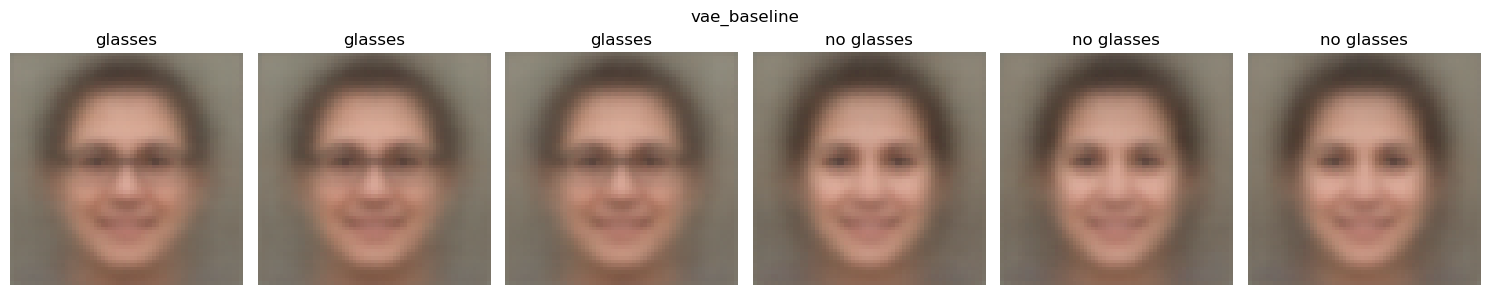

  ✅ Images  → generated/VAE/vae_baseline/
  Computing metrics... 

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\arushaarya/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:14<00:00, 6.48MB/s]


FID=254.88 | 

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\arushaarya/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:12<00:00, 8.70MB/s] 


Prec=0.000 Rec=0.000 | 

c:\Users\arushaarya\miniconda3\envs\py310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\arushaarya\miniconda3\envs\py310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\arushaarya/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:21<00:00, 11.2MB/s] 
c:\Users\arushaarya\miniconda3\envs\py310\lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weight

LPIPS=0.2846

  vae_lr_1e-4
  z_dim=64 | lr=0.0001 | beta=0.5 | activation=leakyrelu | loss=MSE
  Epoch   1/30  loss=0.0492  recon=0.0488  kl=33.7244  beta_now=0.0000


KeyboardInterrupt: 

In [15]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


torch.set_float32_matmul_precision("high")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 30
print(f"Device: {DEVICE}  |  Epochs: {EPOCHS}")

# ── Ablation table ────────────────────────────────────────────────
# One hyperparameter changes per run; everything else stays at baseline.
#
#  Run | Changed HP   | lr    | z_dim | beta | activation | loss_type
#  ----|-------------|-------|-------|------|------------|----------
#   1  | Baseline    | 1e-3  |  64   | 0.5  | leakyrelu  | MSE
#   2  | LR          | 1e-4  |  64   | 0.5  | leakyrelu  | MSE
#   3  | z_dim       | 1e-3  | 128   | 0.5  | leakyrelu  | MSE
#   4  | beta        | 1e-3  |  64   | 2.0  | leakyrelu  | MSE
#   5  | activation  | 1e-3  |  64   | 0.5  | elu        | MSE
#   6  | loss_type   | 1e-3  |  64   | 0.5  | leakyrelu  | L1

ABLATION_CONFIGS = [
    dict(run_tag="vae_baseline",  z_dim=64,  lr=1e-3, beta=0.5, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_lr_1e-4",   z_dim=64,  lr=1e-4, beta=0.5, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_zdim_128",  z_dim=128, lr=1e-3, beta=0.5, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_beta_2",    z_dim=64,  lr=1e-3, beta=2.0, activation="leakyrelu", loss_type="MSE"),
    dict(run_tag="vae_act_elu",   z_dim=64,  lr=1e-3, beta=0.5, activation="elu",       loss_type="MSE"),
    dict(run_tag="vae_loss_l1",   z_dim=64,  lr=1e-3, beta=0.5, activation="leakyrelu", loss_type="L1"),
]

RESULTS = []
for cfg in ABLATION_CONFIGS:
    set_seed(42)
    result = train_vae_ablation(**cfg, epochs=EPOCHS, device=DEVICE)
    RESULTS.append(result)

print("\n🏁 All 6 ablation runs complete.")


In [ ]:
import pandas as pd

# Build and display the ablation results table
df = pd.DataFrame(RESULTS)
df.to_csv("vae_ablation_results.csv", index=False)
# Reorder columns for readability
cols = ["run", "z_dim", "lr", "beta", "activation", "loss_type",
        "final_recon", "final_kl", "fid", "precision", "recall", "lpips"]
df = df[cols]

# Highlight the changed hyperparameter per row in the printout
print("\n" + "="*100)
print("ABLATION TABLE")
# print("="*100)
print(df.to_string(index=False))
# print("="*100)

# Also display as a styled DataFrame in the notebook
try:
    # Bold the column that changed in each row relative to baseline
    changed_cols = [None, "lr", "z_dim", "beta", "activation", "loss_type"]

    def highlight_changed(row):
        styles = [""] * len(row)
        col = changed_cols[df.index.get_loc(row.name)]
        if col and col in row.index:
            idx = list(row.index).index(col)
            styles[idx] = "font-weight: bold; background-color: #fffacd"
        return styles

    display(df.style.apply(highlight_changed, axis=1).format(precision=4))
except Exception:
    display(df)   # fallback if styling fails


---
## Inference Cells
Each cell is **independent** — loads its checkpoint and generates 3+3 images.
Run `load_and_generate` helper cell first.

In [ ]:
# ── Load a saved checkpoint and generate images ───────────────────
def load_and_generate(run_tag: str, device: str = None, n: int = 3):
    torch.manual_seed(42)
    """
    Rebuild the VAE from the saved checkpoint and generate n conditional images.

    The .pt file stores everything needed to reconstruct the model:
        z_dim, activation  →  passed to VAE.__init__()
        model_state        →  loaded via load_state_dict()

    Parameters
    ----------
    run_tag : filename tag used when training  (e.g. "vae_baseline")
    device  : "cuda" / "cpu"  — auto-detected if None
    n       : images per class (default 3, per assignment spec)

    Returns
    -------
    (glasses, no_glasses)  — two (n,3,H,W) float tensors in [0,1]
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    ckpt = torch.load(f"generated/VAE/{run_tag}.pt", map_location=device)

    model = VAE(z_dim=ckpt["z_dim"], activation=ckpt["activation"]).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    print(f"Loaded: generated/VAE/{run_tag}.pt")
    print(f"  z_dim={ckpt['z_dim']}  activation={ckpt['activation']}")

    glasses    = conditional_sampling(model, device, label=1, n=n)
    no_glasses = conditional_sampling(model, device, label=0, n=n)
    visualize_generated(glasses, no_glasses, title=f"Generated — {run_tag}")
    return glasses, no_glasses


print("✅ load_and_generate() ready.")


In [ ]:
# import torch

# torch.manual_seed(42)

In [ ]:
# Run 1 — Baseline   (lr=1e-3 | z_dim=64  | beta=0.5 | leakyrelu | MSE)
glasses_vae_baseline, no_glasses_vae_baseline = load_and_generate("vae_baseline")


In [ ]:
# Run 2 — Lower LR   (lr=1e-4 | z_dim=64  | beta=0.5 | leakyrelu | MSE)
glasses_vae_lr_1e_4, no_glasses_vae_lr_1e_4 = load_and_generate("vae_lr_1e-4")


In [ ]:
# Run 3 — Larger z   (lr=1e-3 | z_dim=128 | beta=0.5 | leakyrelu | MSE)
glasses_vae_zdim_128, no_glasses_vae_zdim_128 = load_and_generate("vae_zdim_128")


In [ ]:
# Run 4 — Stronger KL(lr=1e-3 | z_dim=64  | beta=2.0 | leakyrelu | MSE)
glasses_vae_beta_2, no_glasses_vae_beta_2 = load_and_generate("vae_beta_2")


In [ ]:
# Run 5 — ELU        (lr=1e-3 | z_dim=64  | beta=0.5 | elu       | MSE)
glasses_vae_act_elu, no_glasses_vae_act_elu = load_and_generate("vae_act_elu")


In [ ]:
# Run 6 — L1 loss    (lr=1e-3 | z_dim=64  | beta=0.5 | leakyrelu | L1 )
glasses_vae_loss_l1, no_glasses_vae_loss_l1 = load_and_generate("vae_loss_l1")
